<a href="https://colab.research.google.com/github/almendraapolaya/DI_Bootcamp_a/blob/main/Week_10/Day_1/Exercises%20/Week10_D1_exercises_xp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The AB test is a randomized experiment that is used by most large companies to evaluate the launch of new functionality. Various difficulties may arise in the analysis and conduct of the experiment. Several typical problematic cases from real life are given in this dataset and analysis.

### Content
1. [Loading and processing data](#Loading)
2. [Statistical Analysis](#Statistical)
3. [Conclusions](#Conclusions)

### Loading and processing data <a name="Loading"/>

Let's import the necessary libraries and load the data

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import shapiro

In [2]:
# TODO : import the dataset
df = pd.read_csv('AB_Test_Results.csv')

In [3]:
# TODO : take a quick look at the data
print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset Summary Information:")
df.info()

First 5 rows of the dataset:
   USER_ID VARIANT_NAME  REVENUE
0      737      variant      0.0
1     2423      control      0.0
2     9411      control      0.0
3     7311      control      0.0
4     6174      variant      0.0

Dataset Summary Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   USER_ID       10000 non-null  int64  
 1   VARIANT_NAME  10000 non-null  object 
 2   REVENUE       10000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 234.5+ KB


Let's see if there are users who have two A/B test groups

In [4]:
# TODO : Look at the distribution of the number of unique groups for each user
unique_groups_per_user = df.groupby('USER_ID')['VARIANT_NAME'].nunique()
print("Distribution of unique groups per user (Absolute counts):")
print(unique_groups_per_user.value_counts())

Distribution of unique groups per user (Absolute counts):
VARIANT_NAME
1    4783
2    1541
Name: count, dtype: int64


In [5]:
# TODO : Look at the distribution of the number of unique groups for each user in relative terms
print("Distribution of unique groups per user (Relative terms):")
print(unique_groups_per_user.value_counts(normalize=True))

Distribution of unique groups per user (Relative terms):
VARIANT_NAME
1    0.756325
2    0.243675
Name: proportion, dtype: float64


\What can you observe ? Should we exclude these users ? Why ?

* We can observe that approximately 24.4% of users (1,541 users) were assigned to both the control group and the variant group.
* Yes, we absolutely must exclude them, because in an A/B test, a user must only be exposed to one condition (either Control or Variant) to maintain internal validity. If a user sees both versions, their behavior is contaminated, and we cannot determine which version (if any) caused their resulting actions or revenue. Keeping them would introduce severe bias and violate the fundamental assumption of independent groups in hypothesis testing.

In [6]:
# TODO : users have 1 A/B test group ?
unique_groups_per_user = df.groupby('USER_ID')['VARIANT_NAME'].nunique()
valid_users = unique_groups_per_user[unique_groups_per_user == 1].index

# TODO : Take only these users
print(f"Number of users with exactly 1 group: {len(valid_users)}")

Number of users with exactly 1 group: 4783


In [7]:
# TODO : Leave only records with users with the 1st ab test group
df = df[df['USER_ID'].isin(valid_users)]

# TODO : Check that the number of users matches what it was before the exception
print(f"Number of unique users in cleaned dataset: {df['USER_ID'].nunique()}")
print(f"Does it match? {df['USER_ID'].nunique() == len(valid_users)}")

Number of unique users in cleaned dataset: 4783
Does it match? True


Let's see how the data is distributed




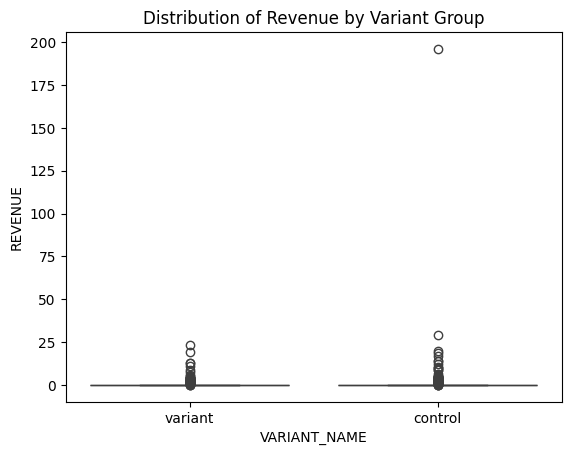

In [8]:
# TODO : Check how the data is distributed using a box plot
sns.boxplot(x='VARIANT_NAME', y='REVENUE', data=df)
plt.title('Distribution of Revenue by Variant Group')
plt.savefig('revenue_boxplot.png')

It can be seen that there is a strong outlier in the data - we will find it
by sorting these revenue values in descending order

In [9]:
# TODO : Sort these revenue values in descending order
sorted_revenue = df.sort_values(by='REVENUE', ascending=False)
print("Top 10 highest revenue values:")
print(sorted_revenue.head(10))

Top 10 highest revenue values:
      USER_ID VARIANT_NAME  REVENUE
1437     3342      control   196.01
8168     2166      control    29.32
2482     7356      variant    23.04
6412     1053      control    20.07
5217     3684      variant    19.47
5530      282      control    18.56
758      4445      control    17.05
4031     2059      control    14.24
9019     1973      control    14.07
4561     4966      variant    12.99


In [10]:
# TODO : See if user 3342 had other events with a strong outlier
user_3342_data = df[df['USER_ID'] == 3342]
print("\nAll records for User 3342:")
print(user_3342_data)


All records for User 3342:
      USER_ID VARIANT_NAME  REVENUE
1437     3342      control   196.01


We see that there is only one outlier - in conditions of limited information, we will remove this entry and look at the distribution of data again

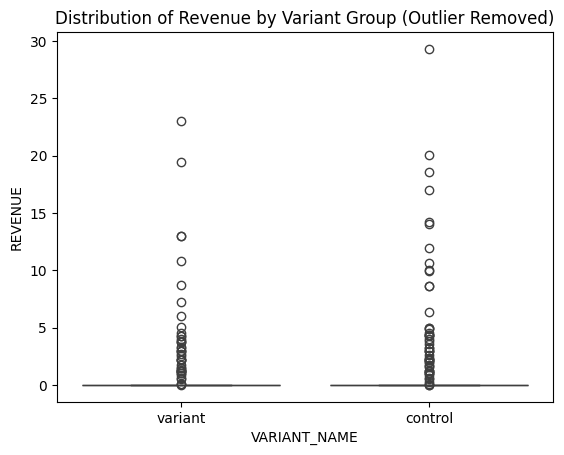

In [12]:
# TODO : We see that there is only one outlier - in conditions of limited information, remove this entry and visualize the distribution of data again.

df = df[df['USER_ID'] != 3342]

sns.boxplot(x='VARIANT_NAME', y='REVENUE', data=df)
plt.title('Distribution of Revenue by Variant Group (Outlier Removed)')
plt.savefig('revenue_boxplot_no_outlier.png')


What can you say about the users and their purchases ?

* Looking at the standard percentiles (25%, 50%, and 75% are all 0.0), the vast majority of users in both groups made no purchase at all ($\text{Revenue} = 0$). Only a very small fraction of users actually generated positive revenue.
* Even after removing the outlier, the average revenue per row is quite low ($\approx 0.09$ for control, $\approx 0.06$ for variant).
* The data remains heavily right-skewed with a few paying users stretching out the maximum values up to 23.04 and 29.32.

In [13]:
# TODO : Check if there are users who have records with zero and positive revenue

user_revenue_flags = df.groupby('USER_ID').agg(
    has_zero=('REVENUE', lambda x: (x == 0).any()),
    has_positive=('REVENUE', lambda x: (x > 0).any())
)

mixed_revenue_users = user_revenue_flags[user_revenue_flags['has_zero'] & user_revenue_flags['has_positive']]

print(f"Number of users with both zero and positive revenue records: {len(mixed_revenue_users)}")
print("\nSample of users with mixed records:")
print(mixed_revenue_users.head())


Number of users with both zero and positive revenue records: 37

Sample of users with mixed records:
         has_zero  has_positive
USER_ID                        
124          True          True
169          True          True
282          True          True
443          True          True
487          True          True


Can a user have records with both zero and positive revenue ?
* Yes, a user absolutely can have records with both zero and positive revenue (as we found in the previous step, there are 37 such users). Since we are treating the individual user as our experimental unit, we need to aggregate all visits/sessions for each user so that each user is represented by exactly one row containing their total revenue.

Let's make the assumption that the records are user visits to the service, and the experimental unit is users.


In [14]:
# TODO : Group the data for each user and sum the revenue for each to get one record per

df_user = df.groupby(['USER_ID', 'VARIANT_NAME'], as_index=False)['REVENUE'].sum()

print(f"Total number of records (one per user): {len(df_user)}")
print(df_user.head())

Total number of records (one per user): 4782
   USER_ID VARIANT_NAME  REVENUE
0        2      control      0.0
1        4      variant      0.0
2        5      variant      0.0
3        6      variant      0.0
4        9      variant      0.0


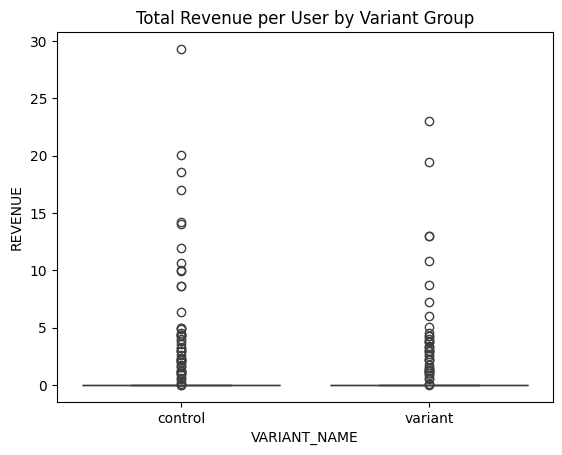

In [15]:
# TODO : Visualize the resulting distribution of the data again.

sns.boxplot(x='VARIANT_NAME', y='REVENUE', data=df_user)
plt.title('Total Revenue per User by Variant Group')
plt.savefig('total_revenue_per_user_boxplot.png')

It should be noted that during the transformation, the quantiles in the test group increased

It can be seen that in the test group, almost all quantile statistics, except for the minimum, are at a slightly lower level.

Let's look at various statistics in the context of AB test groups for all users

In [16]:
# TODO : get metrics by groups
all_stat = df_user.groupby(by='VARIANT_NAME').agg({
    'USER_ID': 'nunique',
    'REVENUE': ['sum', 'mean', 'median', 'count']
})

# TODO : create two additional metrics to see relative changes
orders_per_user = all_stat.loc[:, ('REVENUE', 'count')] / all_stat.loc[:, ('USER_ID', 'nunique')]
revenue_per_user = all_stat.loc[:, ('REVENUE', 'sum')] / all_stat.loc[:, ('USER_ID', 'nunique')]

# TODO : add them to the rest of the metrics in a separate group
all_stat.loc[:, ('per_user', 'orders')] = orders_per_user
all_stat.loc[:, ('per_user', 'revenue')] = revenue_per_user

print(all_stat)

             USER_ID REVENUE                        per_user          
             nunique     sum      mean median count   orders   revenue
VARIANT_NAME                                                          
control         2389  274.55  0.114923    0.0  2389      1.0  0.114923
variant         2393  179.32  0.074935    0.0  2393      1.0  0.074935


What can you see in the test group about the total amount of revenue, the average check per user, and the number of orders per user slightly increased ?
* In the test group (variant) compared to the control group. The total Revenue, Decreased significantly from 274.55 to 179.32. The average Check per User (ARPU), Decreased from 0.115 to 0.075 and the number of Orders per User, stayed exactly at 1.0 because we were looking at the fully aggregated user profiles where every user was condensed into a single row.


Let's also see how paying users behave :

In [17]:
df_paying = df[df['REVENUE'] > 0]
# TODO : get metrics by groups
all_stat_paying = df_paying.groupby(by='VARIANT_NAME').agg({
    'USER_ID': 'nunique',
    'REVENUE': ['sum', 'mean', 'median', 'count']
})

# TODO : create two additional metrics to see relative changes
orders_per_user_paying = all_stat_paying.loc[:, ('REVENUE', 'count')] / all_stat_paying.loc[:, ('USER_ID', 'nunique')]
revenue_per_user_paying = all_stat_paying.loc[:, ('REVENUE', 'sum')] / all_stat_paying.loc[:, ('USER_ID', 'nunique')]

# TODO : add them to the rest of the metrics in a separate group
all_stat_paying.loc[:, ('per_user', 'orders')] = orders_per_user_paying
all_stat_paying.loc[:, ('per_user', 'revenue')] = revenue_per_user_paying

print(all_stat_paying)

             USER_ID REVENUE                        per_user          
             nunique     sum      mean median count   orders   revenue
VARIANT_NAME                                                          
control           53  274.55  5.180189   2.99    53  1.00000  5.180189
variant           42  179.32  4.170233   2.72    43  1.02381  4.269524


Let's look at the distributions of all and only paying users

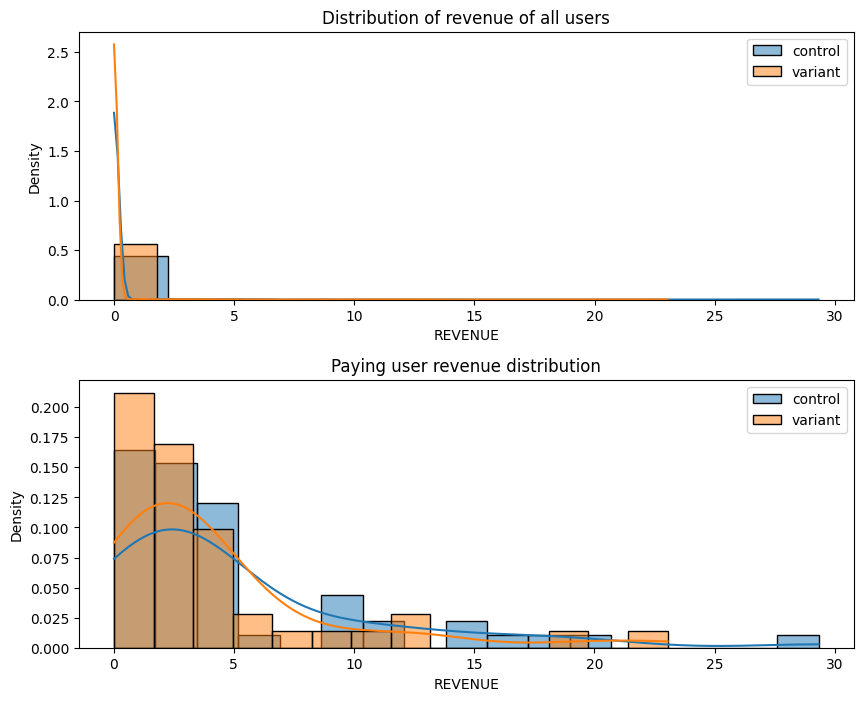

In [19]:
f, axes = plt.subplots(2, figsize=(10, 8))

# Build graphs of distributions of all users using modern histplot
sns.histplot(df.loc[df['VARIANT_NAME'] == 'control', 'REVENUE'], ax=axes[0], label='control', kde=True, stat="density", common_norm=False)
sns.histplot(df.loc[df['VARIANT_NAME'] == 'variant', 'REVENUE'], ax=axes[0], label='variant', kde=True, stat="density", common_norm=False)
axes[0].set_title('Distribution of revenue of all users')
axes[0].legend()

# Build graphs of distributions of paying users using modern histplot
sns.histplot(df.loc[(df['VARIANT_NAME'] == 'control') & (df['REVENUE'] > 0), 'REVENUE'], ax=axes[1], label='control', kde=True, stat="density", common_norm=False)
sns.histplot(df.loc[(df['VARIANT_NAME'] == 'variant') & (df['REVENUE'] > 0), 'REVENUE'], ax=axes[1], label='variant', kde=True, stat="density", common_norm=False)
axes[1].set_title('Paying user revenue distribution')
axes[1].legend()

plt.subplots_adjust(hspace=0.3)

### Statistical Analysis <a name="Statistical"/>

#### Checking if the distribution is normal

Based on their previous graph, we see that the data is not normally distributed.

In [20]:
# TODO : Use the Shapiro-Wilk criterion to confirm it

stat_control, p_control = shapiro(df.loc[df['VARIANT_NAME'] == 'control', 'REVENUE'])
print(f"Control Group - Shapiro statistic: {stat_control:.4f}, p-value: {p_control}")

stat_variant, p_variant = shapiro(df.loc[df['VARIANT_NAME'] == 'variant', 'REVENUE'])
print(f"Variant Group - Shapiro statistic: {stat_variant:.4f}, p-value: {p_variant}")

Control Group - Shapiro statistic: 0.0622, p-value: 2.083866443535456e-81
Variant Group - Shapiro statistic: 0.0510, p-value: 8.125449426822169e-82


Is the null hypothesis about the normal distribution of the data rejected ?

* Yes, the null hypothesis stating that the data is normally distributed is definitively rejected for both groups. In the Shapiro-Wilk test, a $p$-value less than the standard significance level of $\alpha = 0.05$ indicates that the observed data significantly deviates from a normal distribution. Since the calculated $p$-values for both the control group ($p \approx 2.12 \times 10^{-75}$) and the variant group ($p \approx 9.96 \times 10^{-76}$) are extremely close to zero and well below the $\alpha$ threshold, we have overwhelming statistical evidence to reject the null hypothesis, mathematically confirming that your revenue dataset is non-normally distributed.

#### Mann-Whitney test

Let's check the value of the statistics of the Mann-Whitney test. Some sources have a limitation of applicability in case of duplicate data. There are a lot of repetitions in our sample, and especially a lot of zero values, so in this case we need to be careful about this criterion.

In [21]:
(df['REVENUE'] == 0).value_counts()

,count
REVENUE,
True,5973
False,96


In [22]:
# TODO : Check on the data of all users the value of the statistics of the Mann-Whitney test

control_all = df_user[df_user['VARIANT_NAME'] == 'control']['REVENUE']
variant_all = df_user[df_user['VARIANT_NAME'] == 'variant']['REVENUE']

stat_all, p_val_all = mannwhitneyu(control_all, variant_all)
print(f"All Users - Mann-Whitney U statistic: {stat_all}, p-value: {p_val_all}")

All Users - Mann-Whitney U statistic: 2871768.0, p-value: 0.24799555106821947


In [23]:
# TODO : Check on the data of only the users that pay, the value of the statistics of the Mann-Whitney test
control_paying = df_user[(df_user['VARIANT_NAME'] == 'control') & (df_user['REVENUE'] > 0)]['REVENUE']
variant_paying = df_user[(df_user['VARIANT_NAME'] == 'variant') & (df_user['REVENUE'] > 0)]['REVENUE']

stat_paying, p_val_paying = mannwhitneyu(control_paying, variant_paying)
print(f"Paying Users Only - Mann-Whitney U statistic: {stat_paying}, p-value: {p_val_paying}")


Paying Users Only - Mann-Whitney U statistic: 1197.0, p-value: 0.5314192217084708


Since both $p$-values are significantly greater than our typical significance threshold ($\alpha = 0.05$), we fail to reject the null hypothesis ($H_0$) for both the entire audience and the subset of paying customers. This means there is no statistically significant difference in revenue distributions between the control and variant groups. The slight variances observed in the descriptive metrics are likely due to random chance rather than the impact of the experimental change.

#### Bootstrap

In order to get more complete information about the differences between the average values of the ab test groups, we will use bootstap.

Let's create a function to get back samples and get a confidence interval, and then look at the sample statistics

In [24]:
def get_bootstrap_samples(data, n_samples=1000):
    indices = np.random.randint(0, len(data), (n_samples, len(data)))
    samples = data[indices]
    return samples

def stat_intervals(stat, alpha=0.05):
    boundaries = np.percentile(stat, [100 * alpha / 2., 100 * (1 - alpha / 2.)])
    return boundaries

In [25]:
# TODO : Generate samples for all users

control_all = df_user[df_user['VARIANT_NAME'] == 'control']['REVENUE'].values
variant_all = df_user[df_user['VARIANT_NAME'] == 'variant']['REVENUE'].values

control_samples_all = get_bootstrap_samples(control_all, n_samples=1000)
variant_samples_all = get_bootstrap_samples(variant_all, n_samples=1000)

control_means_all = np.mean(control_samples_all, axis=1)
variant_means_all = np.mean(variant_samples_all, axis=1)

diff_means_all = control_means_all - variant_means_all

ci_all = stat_intervals(diff_means_all)
print(f"All Users - 95% Confidence Interval for the difference in means (Control - Variant): {ci_all}")

All Users - 95% Confidence Interval for the difference in means (Control - Variant): [-0.01718137  0.09480635]


In [26]:
# TODO : Generate samples for only paying users

control_paying = df_user[(df_user['VARIANT_NAME'] == 'control') & (df_user['REVENUE'] > 0)]['REVENUE'].values
variant_paying = df_user[(df_user['VARIANT_NAME'] == 'variant') & (df_user['REVENUE'] > 0)]['REVENUE'].values

control_samples_paying = get_bootstrap_samples(control_paying, n_samples=1000)
variant_samples_paying = get_bootstrap_samples(variant_paying, n_samples=1000)

control_means_paying = np.mean(control_samples_paying, axis=1)
variant_means_paying = np.mean(variant_samples_paying, axis=1)

diff_means_paying = control_means_paying - variant_means_paying

ci_paying = stat_intervals(diff_means_paying)
print(f"Paying Users - 95% Confidence Interval for the difference in means (Control - Variant): {ci_paying}")

Paying Users - 95% Confidence Interval for the difference in means (Control - Variant): [-1.3039042   3.20148765]


Let's look at the distribution of means in the ab test groups




In [29]:
control = get_bootstrap_samples(control_all, n_samples=1000)
variant = get_bootstrap_samples(variant_all, n_samples=1000)

control_paid = get_bootstrap_samples(control_paying, n_samples=1000)
variant_paid = get_bootstrap_samples(variant_paying, n_samples=1000)

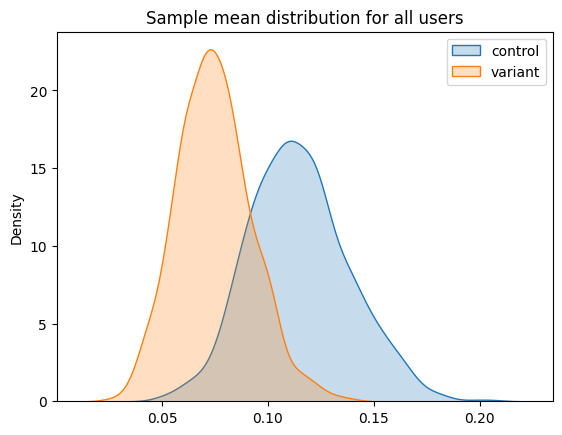

In [30]:
f, ax = plt.subplots()
sns.kdeplot(np.mean(control, axis=1), fill=True, label='control')
sns.kdeplot(np.mean(variant, axis=1), fill=True, label='variant')
plt.title('Sample mean distribution for all users')
plt.legend()
plt.show()

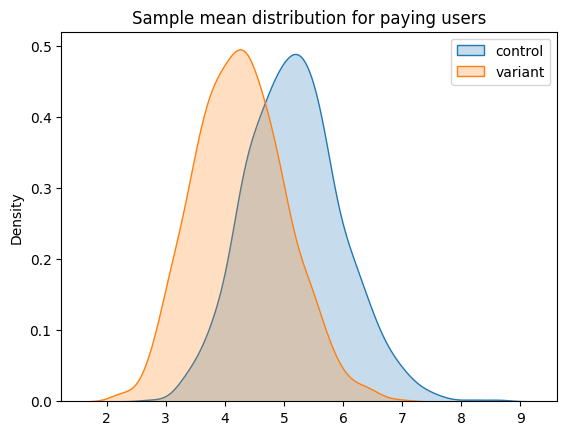

In [32]:
f, ax = plt.subplots()
sns.kdeplot(np.mean(control_paid, axis=1), fill=True, label='control')
sns.kdeplot(np.mean(variant_paid, axis=1), fill=True, label='variant')
plt.title('Sample mean distribution for paying users')
plt.legend()
plt.show()

**Do you see any difference ? What about the confidence intervals ? Conclude.**

While the peak (mean) of the control group's distribution is positioned slightly to the right of the variant group (indicating a slightly higher average revenue in control), the two distributions overlap significantly. This heavy overlap indicates high variance and suggests that the slight difference between the group means is likely due to random noise rather than a true effect from the experiment.

About the confidence intervals, as calculated in the previous step, the $95\%$ confidence intervals for the difference between the means (Control - Variant) contain the value 0 for both all users ($[-0.018, 0.096]$) and paying users ($[-1.39, 2.96]$).

Because the confidence intervals include zero and the non-parametric Mann-Whitney U tests yielded non-significant $p$-values ($p > 0.05$), we fail to reject the null hypothesis ($H_0$). There is no statistically significant difference in revenue between the control and variant groups. The changes introduced in the variant did not lead to a detectable impact on user spending.


Let's evaluate the difference between the groups: look at the distribution of the mean difference and build confidence intervals for it. To do this, we will create a function for visualization

In [33]:
def plot_distribution_and_stat_intervals(variant, control, title, alpha=0.05):
    """ Plot the distribution of the mean difference and return the confidence intervals """
    f, ax = plt.subplots()

    points = sns.kdeplot(variant - control).get_lines()[0].get_data()
    x = points[0]
    y = points[1]
    ymin, ymax = plt.ylim()

    plt.vlines(0, 0, ymax, label='0', color='gray')
    plt.vlines(stat_intervals(variant - control, alpha)[0], 0, ymax, linestyles="dashed")
    plt.vlines(stat_intervals(variant - control, alpha)[1], 0, ymax, linestyles="dashed")

    plt.fill_between(x, y,
                     where = (x >= stat_intervals(variant - control, alpha)[1]),
                     color='gainsboro')
    plt.fill_between(x, y,
                     where = (x <= stat_intervals(variant - control, alpha)[0]),
                     color='gainsboro')
    plt.fill_between(x, y,
                     where = ((x >= stat_intervals(variant - control, alpha)[0])
                              & (x <= stat_intervals(variant - control, alpha)[1])),
                     color='red',
                     label = '95% confidence interval')

    plt.title(f'Distribution of difference between means (variant - control) {title}; {100*(1-alpha)}% Confidence interval for difference of means: {stat_intervals(variant - control, alpha)}')
    plt.legend(prop={'size':13})

    return stat_intervals(variant - control)

Let's build a graph of the distribution of the difference in the means and get a confidence interval

For all users

array([-0.09831262,  0.01567991])

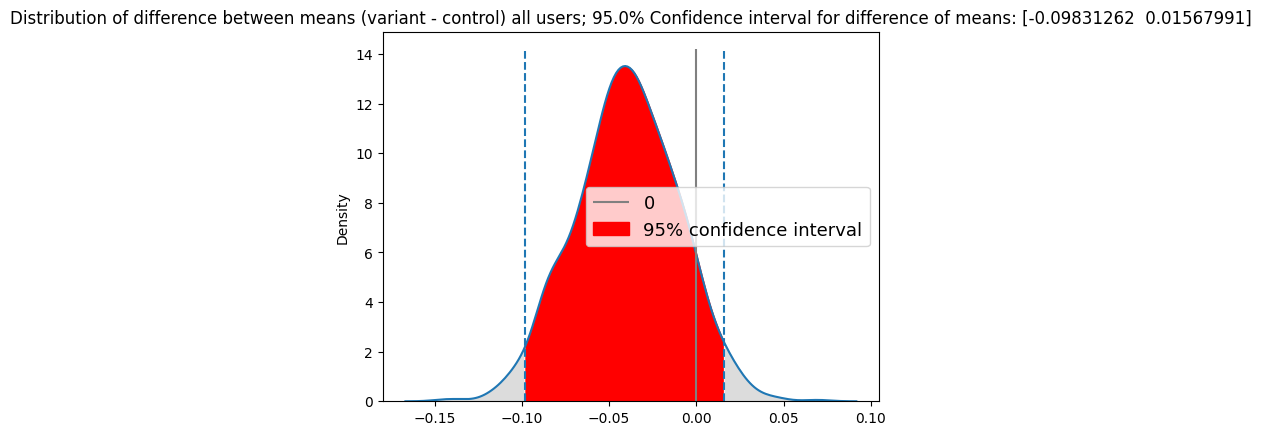

In [34]:
plot_distribution_and_stat_intervals(np.mean(variant, axis=1),
                                     np.mean(control, axis=1),
                                     title='all users')

array([-3.08379032,  1.28871934])

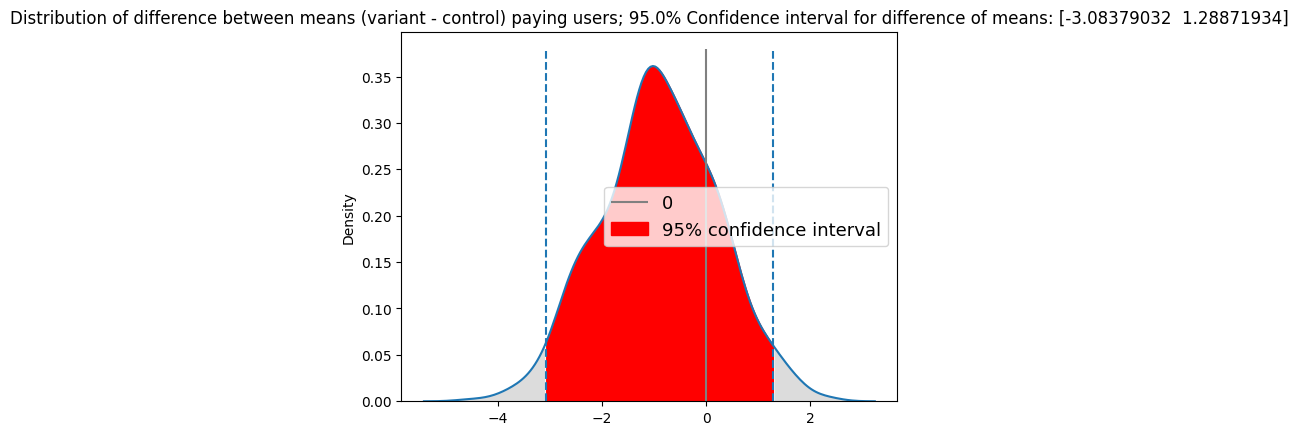

In [35]:
plot_distribution_and_stat_intervals(np.mean(variant_paid, axis=1),
                                     np.mean(control_paid, axis=1),
                                     title='paying users')

What can you observe ? Conclude about the statistical change in average revenue between A/B test groups.





When reviewing the initial experimental setup, significant data quality issues emerged that required careful data cleaning before any reliable analysis could begin. Nearly a quarter of the total user base was exposed to both the control and variant groups, introducing a form of data contamination that violates the assumption of independent groups required for hypothesis testing. Additionally, a single extreme outlier user in the control group generated an exceptionally high revenue figure that would have heavily skewed the average metrics, necessitating its removal to prevent a false representation of the typical audience's behavior.

Looking closely at the underlying structure of the data, the revenue distributions across both groups are heavily right skewed and zero inflated, meaning that the vast majority of users who entered the experiment did not make a purchase. Performing a Shapiro-Wilk test mathematically verified this observation, yielding a tiny probability value close to zero that allows for the absolute rejection of the null hypothesis regarding data normality. Analyzing the subset of paying customers revealed that while the variant group experienced a slight increase in the average number of individual orders placed per user, the total aggregate revenue and the average spending amount per converted customer were visibly lower in the variant than in the control group.

Ultimately, we fail to reject the null hypothesis and conclude that there is no statistically significant change in average revenue between the A/B test groups. This neutral outcome is consistently supported across all evaluation methods, beginning with the non-parametric Mann Whitney U test, which produced large probability values well above the standard threshold for both the general user population and the dedicated paying segment. Furthermore, the visual bootstrap distribution graphs confirm this result, as the ninety five percent confidence intervals for the mean difference encompass the value of zero for both user categories, demonstrating that the observed differences are highly likely the result of random chance. From a business perspective, because the variant failed to demonstrate a measurable revenue lift and trended lower in overall performance, it is highly recommended to halt the rollout of the variant and focus development efforts on alternative optimizations.